In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
df_norm = pd.read_csv('../data/clean_audio_data.csv')
df_norm.head()

,clue_id,clue_word_frequency,duration,clue_latency,clue_number_latency,speech_rate,speech_ratio,articulation_rate,pause_count,pause_mean,...,energy_mean_dev,energy_std_dev,energy_range_dev,energy_p25_dev,energy_p75_dev,jitter_dev,shimmer_dev,hnr_dev,confidence_level,difficulty_level
0,1,0.758687,0.378222,1.483496,-0.746282,-0.106635,-0.203309,-0.246381,1.287504,-0.353398,...,-0.003939,0.004463,0.096480,-0.001506,-0.001961,-0.004079,0.015694,1.644406,medium,low
1,2,-2.284780,-0.543093,-0.463375,0.139763,-0.720194,-1.068199,0.050852,-0.460494,0.665544,...,-0.008999,0.005876,-0.066027,-0.001506,-0.041481,0.004896,0.039277,-2.964881,high,low
2,3,0.994141,-0.863681,-0.838843,1.468831,2.448223,0.441978,1.694925,-0.798816,-1.487240,...,0.024711,-0.024349,-0.286796,-0.001506,0.075795,0.001324,0.006339,0.182086,high,low
3,4,-0.252896,-0.146104,0.516020,-0.746282,-0.639957,-0.965797,-0.354685,0.159763,0.558579,...,-0.008186,0.004418,0.028319,-0.001506,-0.039224,0.008951,0.034387,-4.907182,low,high
4,5,-0.261616,0.629898,-0.669982,-0.398193,0.334273,1.421530,-0.528518,-0.404107,-0.518866,...,0.002208,0.001413,0.001481,0.004335,-0.010968,0.000528,-0.003851,0.088245,high,medium


In [5]:
df_norm.drop(columns=['participant_id'], inplace=True)

## Reduce feature set based on previous EDA

In [6]:
selected_features = [

    # -------------------------
    # ⏱️ Timing / fluency (core)
    # -------------------------
    "duration",
    "speech_rate",
    "pause_count",
    "pause_mid_speech",
    "pause_max",
    "filler_count",
    "verbal_hesitation_count",

    # -------------------------
    # 🔁 Relative (VERY important)
    # -------------------------
    "duration_dev",
    "speech_rate_dev",
    "pause_count_dev",
    "pause_mid_speech_dev",
    "filler_count_dev",
    "verbal_hesitation_count_dev",

    # -------------------------
    # 🔊 Energy (strongest signal)
    # -------------------------
    "energy_mean",
    "energy_std",
    "energy_range",

    "energy_mean_dev",
    "energy_std_dev",
    "energy_range_dev",

    # -------------------------
    # 🎤 Voice quality (light)
    # -------------------------
    "hnr",
    "hnr_dev",

    # -------------------------
    # 🎵 Minimal spectral (optional)
    # -------------------------
    "mfcc_2_mean",
    "mfcc_2_mean_dev",
]

## 1. Predicting Confidence

In [9]:
X = df_norm[selected_features]
y = df_norm['confidence_level']

In [12]:
# check class balance
y.value_counts(normalize=True)

confidence_level
high      0.507042
medium    0.281690
low       0.211268
Name: proportion, dtype: float64

In [13]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [14]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [15]:
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        high       0.78      0.88      0.82         8
         low       0.33      0.33      0.33         3
      medium       0.33      0.25      0.29         4

    accuracy                           0.60        15
   macro avg       0.48      0.49      0.48        15
weighted avg       0.57      0.60      0.58        15



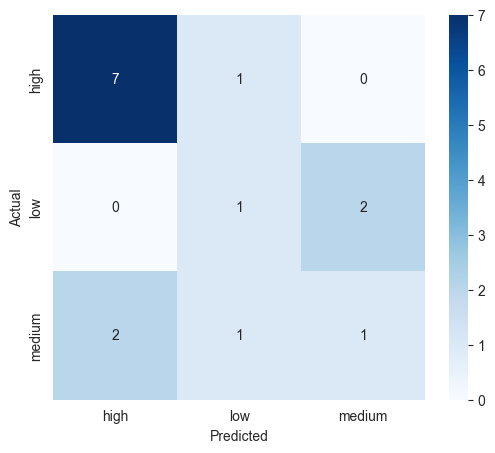

In [16]:
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
cm_df = pd.DataFrame(cm, index=rf.classes_, columns=rf.classes_)

plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

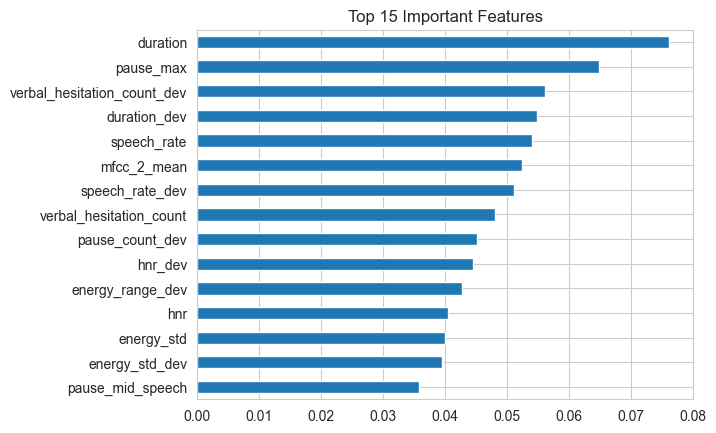

In [17]:
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False)
feat_imp.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 Important Features")
plt.show()

In [18]:
feat_imp.head(20)

duration                       0.076195
pause_max                      0.064795
verbal_hesitation_count_dev    0.056078
duration_dev                   0.054881
speech_rate                    0.053988
mfcc_2_mean                    0.052423
speech_rate_dev                0.051189
verbal_hesitation_count        0.047987
pause_count_dev                0.045076
hnr_dev                        0.044476
energy_range_dev               0.042795
hnr                            0.040483
energy_std                     0.040000
energy_std_dev                 0.039510
pause_mid_speech               0.035866
pause_mid_speech_dev           0.035243
pause_count                    0.035148
energy_mean                    0.034866
energy_range                   0.033534
energy_mean_dev                0.033203
dtype: float64

## 2. Predicting Difficulty

In [20]:
X = df_norm[selected_features]
y = df_norm['difficulty_level']

In [21]:
# check class balance
y.value_counts(normalize=True)

difficulty_level
low       0.549296
high      0.253521
medium    0.197183
Name: proportion, dtype: float64

In [22]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [23]:
print(y_train.value_counts(normalize=True))

difficulty_level
low       0.553571
high      0.250000
medium    0.196429
Name: proportion, dtype: float64


In [24]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

              precision    recall  f1-score   support

        high       0.40      0.50      0.44         4
         low       0.60      0.75      0.67         8
      medium       0.00      0.00      0.00         3

    accuracy                           0.53        15
   macro avg       0.33      0.42      0.37        15
weighted avg       0.43      0.53      0.47        15



/Users/clara/Desktop/VU/Thesis/beyond-speech-hri/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/clara/Desktop/VU/Thesis/beyond-speech-hri/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/clara/Desktop/VU/Thesis/beyond-speech-hri/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

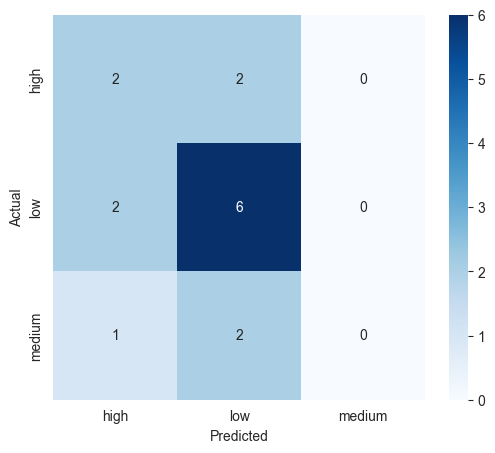

In [25]:
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
cm_df = pd.DataFrame(cm, index=rf.classes_, columns=rf.classes_)

plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

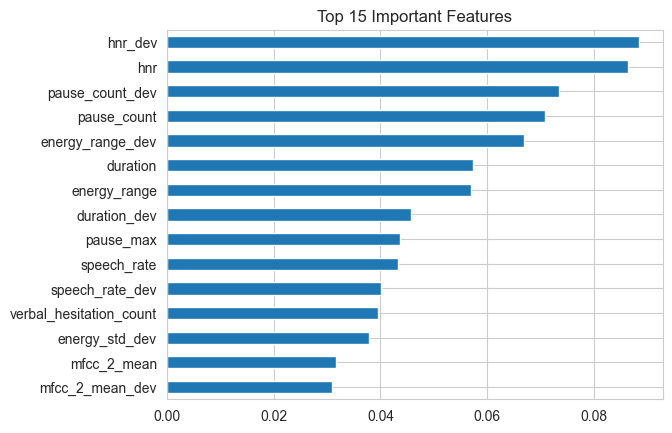

In [26]:
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False)
feat_imp.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 Important Features")
plt.show()

In [27]:
feat_imp.head(20)

hnr_dev                        0.088477
hnr                            0.086396
pause_count_dev                0.073531
pause_count                    0.070816
energy_range_dev               0.066963
duration                       0.057361
energy_range                   0.056995
duration_dev                   0.045710
pause_max                      0.043662
speech_rate                    0.043371
speech_rate_dev                0.040127
verbal_hesitation_count        0.039530
energy_std_dev                 0.037827
mfcc_2_mean                    0.031607
mfcc_2_mean_dev                0.030914
energy_mean                    0.030144
energy_mean_dev                0.028827
verbal_hesitation_count_dev    0.028741
energy_std                     0.026257
pause_mid_speech_dev           0.022950
dtype: float64